<a href="https://colab.research.google.com/github/tur-learning/STAT2103-biz/blob/cinema-troisi/notebooks/11_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🎯 We’re now diving into one of the most powerful tools in statistics — **simple linear regression**! Whether you're predicting sales, salaries, or stock movements, regression gives you a framework to connect two variables through a probabilistic lens.


## **📌Section 11.1 – Probabilistic Models**:


---

### 📌 **Key Concepts**

#### 🎯 **Goal**
Model the relationship between a **dependent variable** $ y $ (e.g., sales revenue, % outsourced jobs) and an **independent variable** $ x $ (e.g., advertising spend, company size).

---

#### 🔗 **Deterministic vs Probabilistic Models**
- **Deterministic**: $ y = \beta_0 + \beta_1 x $
  - Predicts $ y $ with certainty from $ x $
  - Unrealistic in most real-world scenarios
- **Probabilistic**: $ y = \beta_0 + \beta_1 x + \varepsilon $
  - Accounts for random error $ \varepsilon $
  - More realistic: Not all companies with the same number of employees will outsource the same %

---

#### 📈 **The Probabilistic Model Structure**
- $ y $: dependent variable (response)
- $ x $: independent variable (predictor)
- $ \beta_0 $: y-intercept (value of $ y $ when $ x = 0 $)
- $ \beta_1 $: slope (change in mean $ y $ per unit change in $ x $)
- $ \varepsilon $: random error (with mean 0 and constant variance)

---

#### 🧪 **Example: Outsourcing Jobs**
- **Experimental unit**: A U.S. company
- **$ y $**: % of jobs outsourced (dependent)
- **$ x $**: company size (independent)
- **Model**: $ y = \beta_0 + \beta_1 x + \varepsilon $

---

Let's walk through a **step-by-step simple linear regression analysis** using the **Legal Advertising** dataset. We'll follow the classic five-step modeling process introduced in Section 11.1.

### 🔢 **Step 1: Hypothesize the Deterministic Component**

We want to explore whether **advertising expenditure** (x) affects the number of **new PI cases** (y).

**Model form:**

\begin{align}
y = \beta_0 + \beta_1 x + \varepsilon
\end{align}

Where:
- $ y $: Number of new PI cases in a month (dependent variable)
- $ x $: Monthly advertising expenditure in dollars (independent variable)
- $ \varepsilon $: Random error (captures effects of other variables like seasonality, economy, etc.)

---

### 📊 **Step 2: Estimate Unknown Parameters $ \beta_0 $ and $ \beta_1 $**

We'll use the **least squares approach** to estimate the slope ($ \beta_1 $) and intercept ($ \beta_0 $) using the actual data.

Let’s extract:
- $ x_i $: advertising expenditure
- $ y_i $: new PI cases

You’ve already provided the dataset up to 48 months. We'll select the months where both $ x_i $ and $ y_i $ are available (and exclude months with missing ad expenditures).

I can now compute:
- $ \hat{\beta}_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2} $
- $ \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x} $


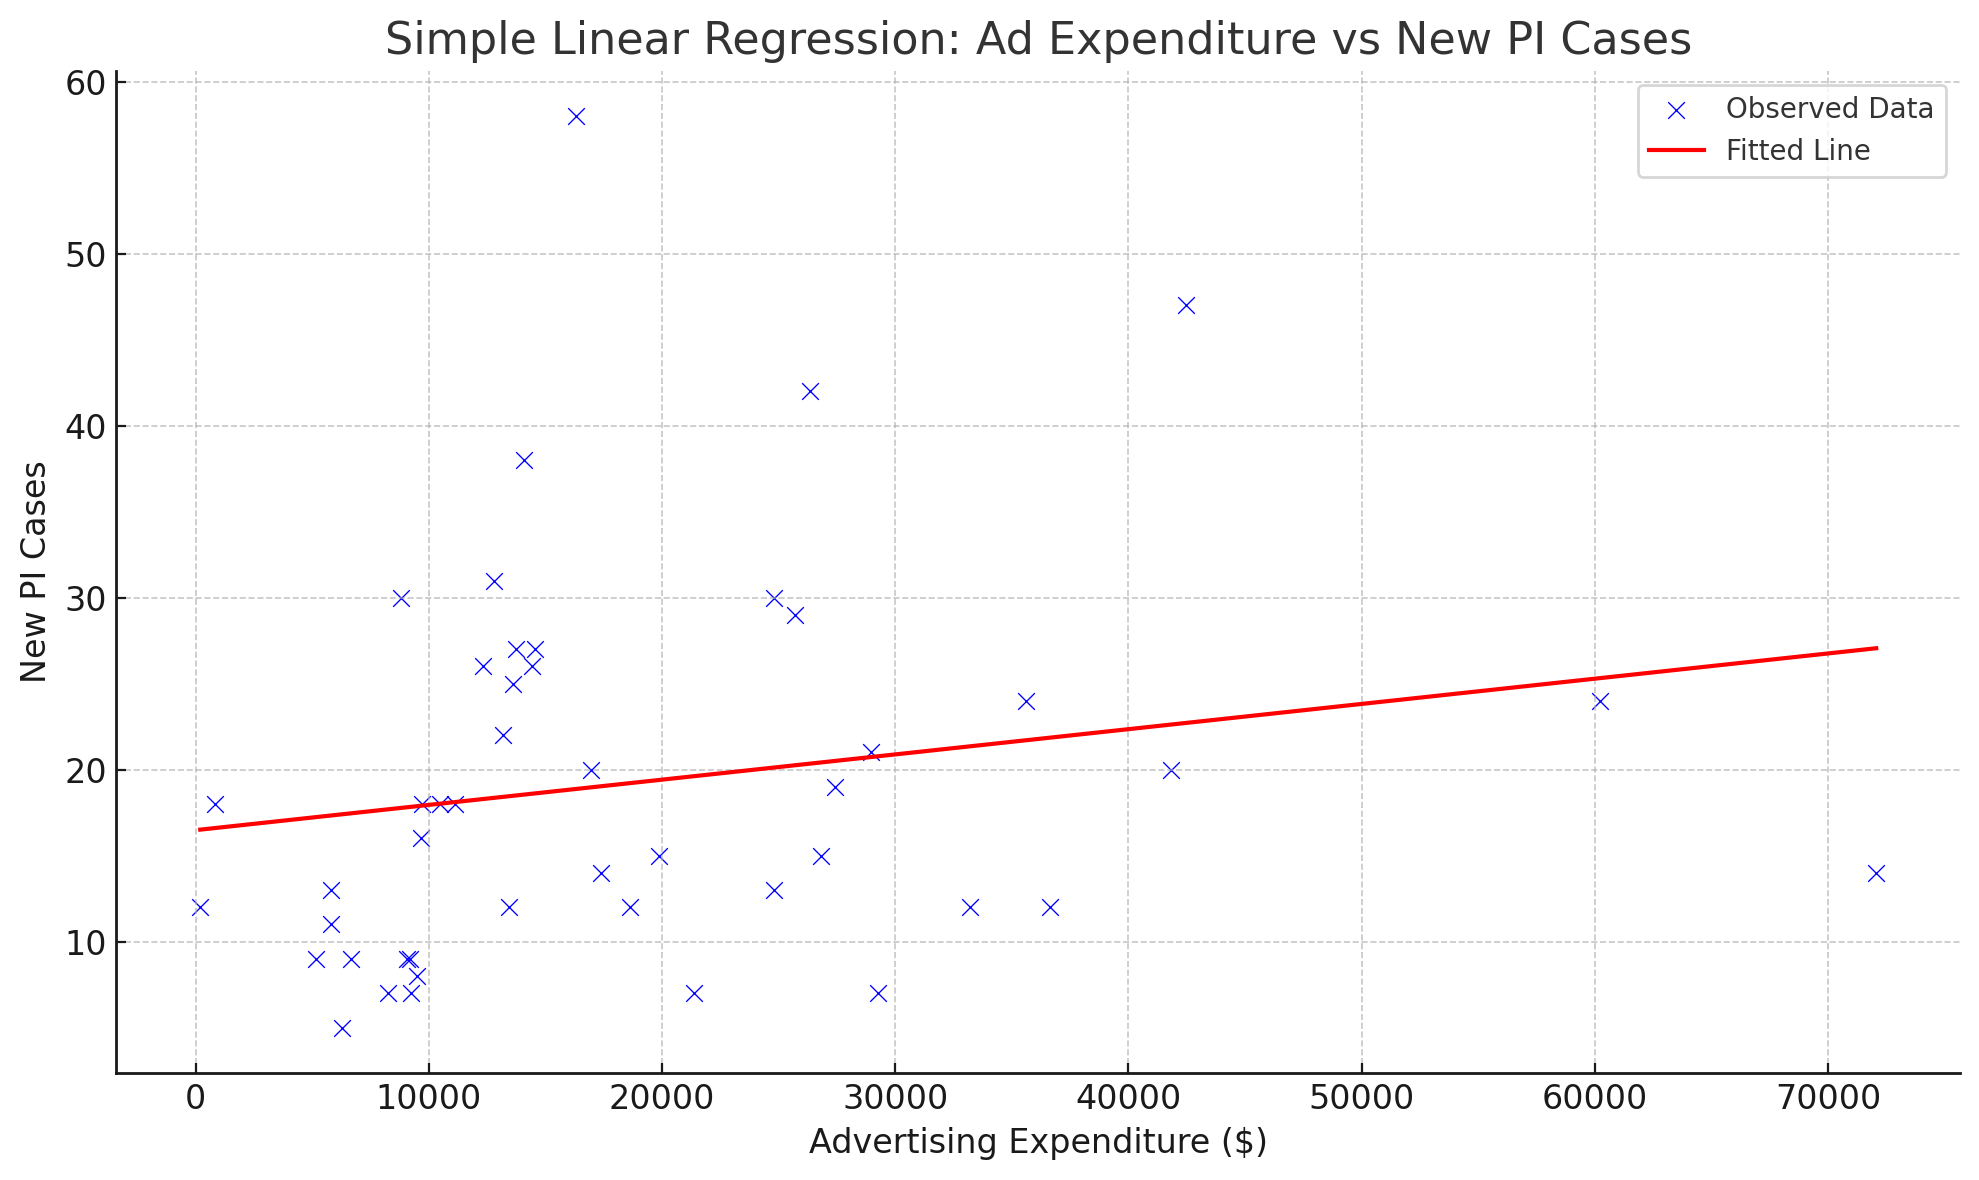

Here's the regression analysis using your **Legal Advertising** dataset.

---

### ✅ **Step 2: Least Squares Estimation**

We modeled the number of new PI cases (`y`) based on monthly advertising expenditure (`x`), and estimated the parameters of the regression line:

\begin{align}
\hat{y} = 16.483 + 0.000147 \cdot x
\end{align}

- **Intercept** ($ \hat{\beta}_0 $) ≈ **16.48**  
- **Slope** ($ \hat{\beta}_1 $) ≈ **0.000147**

This means that for every additional dollar spent on advertising, we estimate **0.000147** more new PI cases per month—i.e., **about 1 additional case per \$6,770 spent**.

---

### 📉 **Interpretation of the Model Fit**

From the **regression summary**:

- **R-squared** = **0.036** → Only **3.6%** of the variation in new PI cases is explained by ad expenditure.
- **F-statistic p-value** = **0.202** → The slope is **not statistically significant** at the 5% level.
- **t-test on slope**:  
  - p-value = 0.202 → Fail to reject $ H_0 : \beta_1 = 0 $
  - Conclusion: No significant evidence that ad expenditure affects PI case count in this model.

---

### 🔍 **Next Steps in the Model**

We'll continue to:
- Step 3: **Assess the model assumptions** (normality, homoscedasticity)
- Step 4: **Evaluate the slope more deeply**
- Step 5: **Use the model for prediction (e.g., for \$30,000 in ads)**

Would you like to go to **Step 3** now and check if the model assumptions hold (e.g., residual plots, normality tests)?

---

## 📌 11.3 Model Assumptions (Theory)

In simple linear regression, we assume the relationship:

\begin{align}
y = \beta_0 + \beta_1 x + \varepsilon
\end{align}

Where:
- $ \beta_0 $: y-intercept (constant)
- $ \beta_1 $: slope
- $ \varepsilon $: random error

---

### ✅ Key Assumptions

1. **Linearity**: $ \mathbb{E}(y | x) = \beta_0 + \beta_1 x $
2. **Homoscedasticity**: Constant variance of errors → $ \text{Var}(\varepsilon) = \sigma^2 $
3. **Normality**: Errors are normally distributed
4. **Independence**: Errors are independent from one another

If these assumptions hold, we can **trust** our slope and intercept estimates, and build valid confidence intervals and hypothesis tests.

---

### 📊 Visualizing Assumptions

Let’s illustrate with a synthetic linear model:

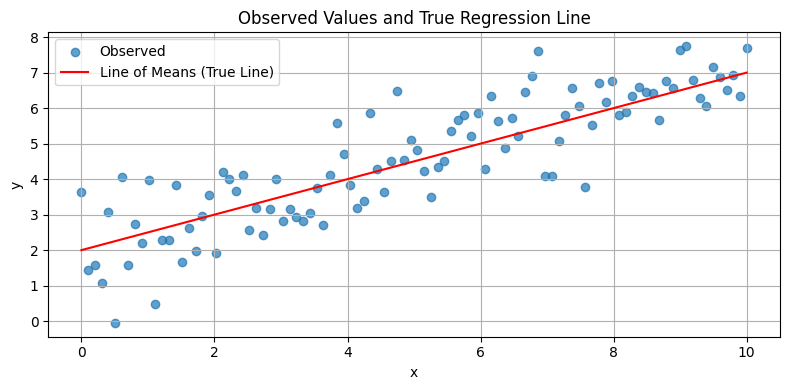

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(1)
x = np.linspace(0, 10, 100)
y_true = 2 + 0.5 * x
errors = np.random.normal(0, 1, size=len(x))  # ε ~ N(0, σ²)
y_obs = y_true + errors

plt.figure(figsize=(8, 4))
plt.scatter(x, y_obs, alpha=0.7, label='Observed')
plt.plot(x, y_true, color='red', label='Line of Means (True Line)')
plt.title("Observed Values and True Regression Line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---

### 📐 Estimating the Error Variance

To assess prediction reliability, we estimate the variance of residuals:

\begin{align}
s^2 = \frac{\text{SSE}}{n - 2}, \quad \text{where } \text{SSE} = \sum (y_i - \hat{y}_i)^2
\end{align}

In [ ]:
import statsmodels.api as sm

X = sm.add_constant(x)
model = sm.OLS(y_obs, X).fit()

s_squared = model.mse_resid  # Estimated variance of ε
s = np.sqrt(s_squared)       # Standard error of regression

print(f"Estimated error variance (s²): {s_squared:.3f}")
print(f"Estimated standard error (s): {s:.3f}")

Estimated error variance (s²): 0.790
Estimated standard error (s): 0.889


---

### 🧠 Interpretation

- $ s $ is the **standard deviation of residuals** (vertical spread around the line).
- Most observed values of $ y $ should fall within $ \hat{y} \pm 2s $.

---

## 🔍 11.4 Assessing the Utility of the Model: Is the Slope Useful?

We test if the independent variable $ x $ contributes to predicting the response variable $ y $.


---

### 🧪 Hypothesis Test on the Slope $ \beta_1 $

We test:

\begin{align}
H_0: \beta_1 = 0 \quad \text{(no linear relationship)} \\
H_1: \beta_1 \neq 0 \quad \text{(linear relationship exists)}
\end{align}

---

### ✅ Test Statistic

\begin{align}
t = \frac{b_1 - 0}{s_{b_1}} \quad \text{with } n - 2 \text{ degrees of freedom}
\end{align}

Where:
- $ b_1 $: estimated slope
- $ s_{b_1} = \frac{s}{\sqrt{\sum (x_i - \bar{x})^2}} $: std. error of the slope

---

### 🔎 Example — Advertising and Sales Data

In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Advertising-Sales Example (Section 11.2)
x = np.array([1, 2, 3, 4, 5])  # $100s
y = np.array([1, 1, 2, 2, 4])  # $1000s

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     13.36
Date:                Thu, 03 Apr 2025   Prob (F-statistic):             0.0354
Time:                        13:03:56   Log-Likelihood:                -3.3094
No. Observations:                   5   AIC:                             10.62
Df Residuals:                       3   BIC:                             9.838
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1000      0.635     -0.157      0.8

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


---

### 📈 Interpreting the Output

- **p-value** for $ b_1 $: tests if slope ≠ 0
- **Reject $ H_0 $** if $ p < \alpha $ (e.g., 0.05)
- **Confidence Interval** for $ \beta_1 $: If it doesn't include 0, we conclude a significant relationship.

---

### 🧠 Interpretation Example

In [ ]:
slope = model.params[1]
conf_int = model.conf_int().loc[1]

print(f"Slope b1 = {slope:.3f}")
print(f"95% CI for slope: [{conf_int[0]:.3f}, {conf_int[1]:.3f}]")

if conf_int[0] > 0 or conf_int[1] < 0:
    print("✅ Slope is significantly different from 0.")
else:
    print("⚠️ Slope is not significantly different from 0.")

---

### 💡 Insight

- If $ \beta_1 = 0 $, advertising has **no effect** on revenue.
- If $ \beta_1 \neq 0 $, advertising **is useful** in predicting sales.
- Always interpret results **within the range of your data**.

---

## 📊 11.5 Coefficients of Correlation and Determination

These two statistics help assess the **strength** and **explanatory power** of a regression model.

---

### 🔁 Coefficient of Correlation (r)

The **correlation coefficient** $ r \in [-1, 1] $ measures the strength and direction of a **linear** relationship between two variables:

- $ r > 0 $: Positive correlation (as x increases, y tends to increase)
- $ r < 0 $: Negative correlation (as x increases, y tends to decrease)
- $ r \approx 0 $: No linear relationship
- $ |r| \approx 1 $: Strong linear relationship

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Example: Advertising and Sales (Section 11.2)
x = np.array([1, 2, 3, 4, 5])  # Advertising ($100s)
y = np.array([1, 1, 2, 2, 4])  # Sales ($1000s)

r, _ = stats.pearsonr(x, y)
print(f"Correlation coefficient (r): {r:.3f}")

Correlation coefficient (r): 0.904


---

### 📐 Coefficient of Determination (R²)

The **coefficient of determination** $ R^2 $ represents the **proportion of variation in y explained by x** in the model:

\begin{align}
R^2 = r^2
\end{align}

- $ R^2 = 0.82 $ means **82%** of the variance in y is explained by x.

In [ ]:
R_squared = r**2
print(f"Coefficient of Determination (R²): {R_squared:.3f}")

Coefficient of Determination (R²): 0.817


---

### 🧠 Interpretation

- **r** tells us *how strongly* x and y are linearly related.
- **R²** tells us *how much* of the variability in y is explained by x.

---

### 🔎 Visualizing Correlation Strength

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

# Strong positive
axs[0].scatter(x, x + np.random.normal(0, 0.2, size=len(x)))
axs[0].set_title("Strong Positive Correlation")

# Weak
axs[1].scatter(x, np.random.normal(0, 1, size=len(x)))
axs[1].set_title("No Linear Correlation")

# Strong negative
axs[2].scatter(x, -x + np.random.normal(0, 0.2, size=len(x)))
axs[2].set_title("Strong Negative Correlation")

for ax in axs:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
plt.tight_layout()
plt.show()

---

### ⚠️ Cautions with r and R²

- **Correlation ≠ Causation**
- A **low r** doesn’t rule out **nonlinear** relationships.
- **High R²** doesn’t mean the model is **appropriate**.

---

## 📈 11.6 Using the Model for Estimation and Prediction

Once we’re confident in the model, we can **estimate** the mean value of y for a given x or **predict** a new y value for that x.

---

### 🔍 Two Types of Use

1. **Estimate Mean of y** for all units at a specific x (e.g., average revenue for \$400 in ads).
2. **Predict New y** for one specific case at that x (e.g., next month’s revenue).

🔸 **Estimation** is more accurate than **prediction**.

---

### 🧮 Recap: Least Squares Line

We use the fitted model:

\begin{align}
\hat{y} = b_0 + b_1 x
\end{align}

To estimate both:
- The mean value of y, $ E(y|x) $
- A new individual value of y

---

### 🔢 Example (Advertising-Sales Data)

In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Data
x = np.array([1, 2, 3, 4, 5])  # Advertising ($100s)
y = np.array([1, 1, 2, 2, 4])  # Sales ($1000s)

# Add intercept for statsmodels
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

# Predict for x = 4 ($400 in ads)
x0 = 4
X0 = sm.add_constant(np.array([x0]))
pred = model.get_prediction(X0)

# Confidence & prediction intervals
summary_frame = pred.summary_frame(alpha=0.05)
summary_frame

ValueError: shapes (1,1) and (2,) not aligned: 1 (dim 1) != 2 (dim 0)

---

### 📦 Interpretation of Output

- **mean** → Estimate of $ E(y|x_0) $
- **mean_ci_lower**, **mean_ci_upper** → CI for mean
- **obs_ci_lower**, **obs_ci_upper** → Prediction Interval for individual

🧠 **Prediction intervals are wider** because they include both model uncertainty **and** random noise.

---

### 📊 Visualize: CI vs PI

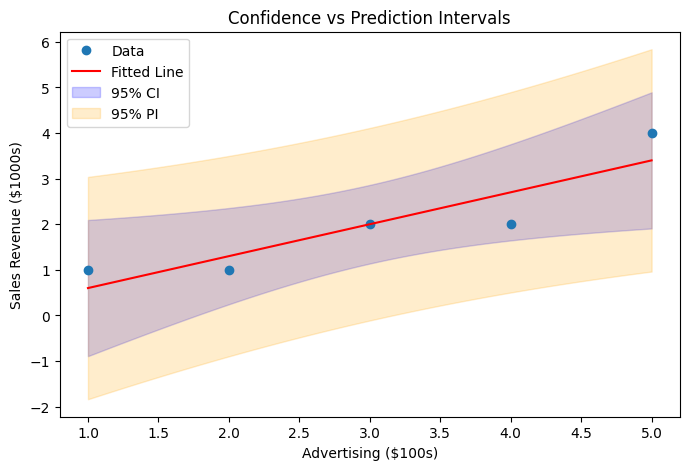

In [ ]:
x_range = np.linspace(min(x), max(x), 100)
X_range = sm.add_constant(x_range)
preds = model.get_prediction(X_range).summary_frame()

plt.figure(figsize=(8, 5))
plt.plot(x, y, 'o', label='Data')
plt.plot(x_range, preds['mean'], 'r-', label='Fitted Line')
plt.fill_between(x_range, preds['mean_ci_lower'], preds['mean_ci_upper'], color='blue', alpha=0.2, label='95% CI')
plt.fill_between(x_range, preds['obs_ci_lower'], preds['obs_ci_upper'], color='orange', alpha=0.2, label='95% PI')
plt.legend()
plt.xlabel("Advertising ($100s)")
plt.ylabel("Sales Revenue ($1000s)")
plt.title("Confidence vs Prediction Intervals")
plt.show()

---

### ⚠️ Caution: Don’t Predict Outside the Sample Range

Predictions for x-values **outside the sample** can be **highly unreliable**.

> 📉 Accuracy drops the farther x is from the sample mean $ \bar{x} $

---

## 🧪 11.7 A Complete Example: Fire Damage vs. Distance to Fire Station

We’ll model **fire damage** (in $1,000s) as a function of **distance** (in miles) from the nearest fire station.

---

### 🔧 Step 1: Hypothesize the Model

Assume a straight-line model:  
\begin{align}
y = \beta_0 + \beta_1 x + \varepsilon
\end{align}

---

### 📊 Step 2: Load Data and Fit Model

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Data
x = np.array([3.4, 1.8, 4.6, 2.3, 3.1, 5.5, 0.7, 3.0, 2.6, 4.3, 2.1, 1.1, 6.1, 4.8, 3.8])
y = np.array([26.2, 17.8, 31.3, 23.1, 27.5, 36.0, 14.1, 22.3, 19.6, 31.3, 24.0, 17.3, 43.2, 36.4, 26.1])

# Fit regression model
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

# Summary
model.summary()

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                     156.9
Date:                Mon, 07 Apr 2025   Prob (F-statistic):           1.25e-08
Time:                        20:09:02   Log-Likelihood:                -32.811
No. Observations:                  15   AIC:                             69.62
Df Residuals:                      13   BIC:                             71.04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.2779      1.420      7.237      0.000       7.210      13.346
x1             4.9193      0.393     12.525      0.000       4.071       5.768
==============================================================================
Omnibus:                        2.551   Durbin-Watson:                   1.318
Prob(Omnibus):                  0.279   Jarque-Bera (JB):                1.047
Skew:                          -0.003   Prob(JB):                        0.592
Kurtosis:                       1.706   Cond. No.                         9.13
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

---

### 📈 Step 3: Visualize the Fit

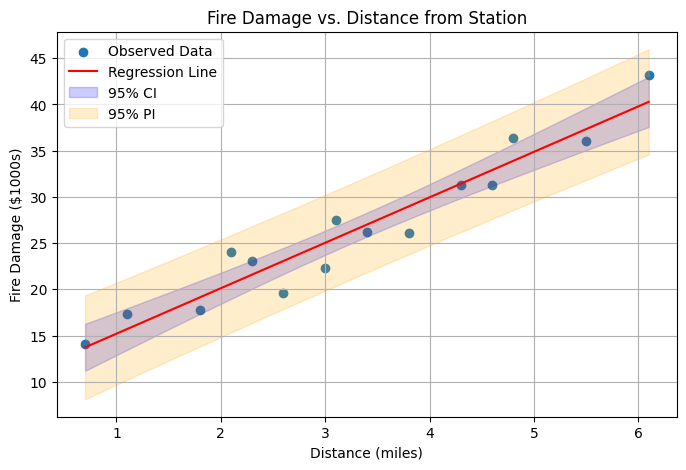

In [ ]:
# Prediction line
x_range = np.linspace(min(x), max(x), 100)
X_range = sm.add_constant(x_range)
preds = model.get_prediction(X_range).summary_frame()

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Observed Data")
plt.plot(x_range, preds["mean"], 'r-', label="Regression Line")
plt.fill_between(x_range, preds["mean_ci_lower"], preds["mean_ci_upper"], color='blue', alpha=0.2, label="95% CI")
plt.fill_between(x_range, preds["obs_ci_lower"], preds["obs_ci_upper"], color='orange', alpha=0.2, label="95% PI")
plt.xlabel("Distance (miles)")
plt.ylabel("Fire Damage ($1000s)")
plt.title("Fire Damage vs. Distance from Station")
plt.legend()
plt.grid(True)
plt.show()

---

### ✅ Step 4: Interpret Model Utility

- **Slope**: $\hat{\beta}_1$ ≈ increase of **\$4,919** in fire damage per mile.
- **Intercept**: $\hat{\beta}_0$ ≈ \$10,278 —**not meaningful** as 0 is outside the sample range.
- **$R^2$ (Coefficient of Determination)**: Tells us how much of the variation in damage is explained by distance.
- **$p$-value for slope**: Very small → strong evidence of a relationship.

---

### 📉 Step 5: Estimate and Predict at x = 3.5

In [ ]:
x0 = 3.5
X0 = sm.add_constant(np.array([x0]))
pred = model.get_prediction(X0).summary_frame(alpha=0.05)
pred

ValueError: shapes (1,1) and (2,) not aligned: 1 (dim 1) != 2 (dim 0)

> 🎯 **Estimated mean damage**: ~\$27,495  
> 🔮 **95% Prediction Interval**: \$22,324 to \$32,667

---

### ⚠️ Caution: Don’t Extrapolate

The model is only valid for:
\begin{align}
0.7 \leq x \leq 6.1 \text{ miles}
\end{align}

> Extrapolating outside this range can produce misleading or invalid results.